#TASk 1

In [106]:
import torch 
from torch import nn
from torch import optim
import torchvision
import torchvision.datasets as datasets
from torchvision import transforms
from torch.utils.data import DataLoader
import os 


In [107]:
transform = transforms.ToTensor() #data is converted to a tensor and normalized to [0,1]


mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)#60000 images, 28x28 pixels, 1 channel (grayscale)
mnist_testset=datasets.MNIST(root='./data', train=False, download=True, transform=transform)#10000 images, 28x28 pixels, 1 channel (grayscale)



In [108]:
img, label = mnist_trainset[0]

print(type(img), img.dtype)          # <class 'torch.Tensor'> torch.float32
print(img.shape)                     # torch.Size([1, 28, 28])
print(img.min().item(), img.max().item())   # [0,1]
print(label, type(label))            # 5 'int'
print(len(mnist_trainset), len(mnist_testset))   # 60000 10000


<class 'torch.Tensor'> torch.float32
torch.Size([1, 28, 28])
0.0 1.0
5 <class 'int'>
60000 10000


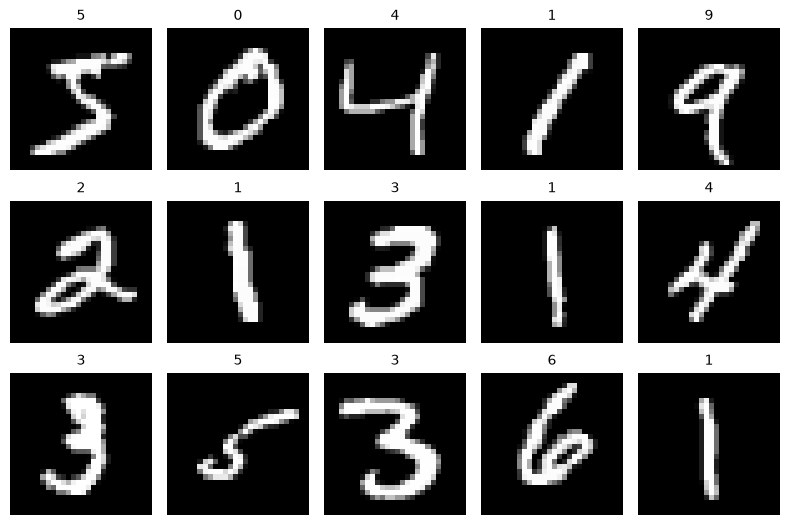

In [109]:
import matplotlib.pyplot as plt

n_rows, n_cols = 3, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.6, n_rows * 1.8))

for ax, idx in zip(axes.flat, range(n_rows * n_cols)):
    img, label = mnist_trainset[idx]      # img: tensor shape (1, 28, 28)
    ax.imshow(img.squeeze(), cmap='gray') # squeeze() drops the channel -> (28, 28)
    ax.set_title(str(label), fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


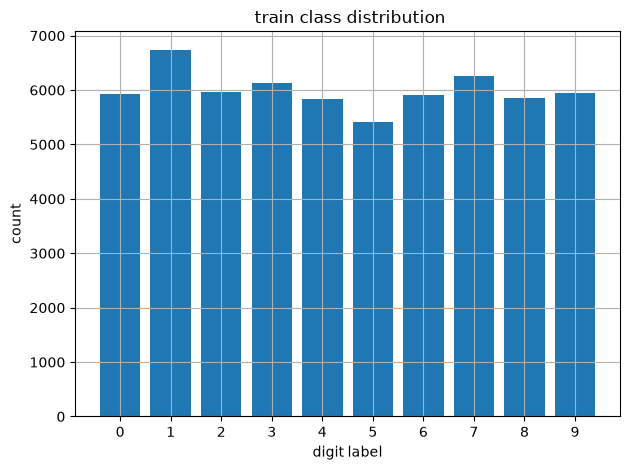

In [110]:

targets = mnist_trainset.targets          # all 60000 labels, 0..9
counts = torch.bincount(targets)          #  how many images are digit d

plt.bar(range(10), counts.tolist()) 
plt.xlabel("digit label")
plt.ylabel("count")
plt.xticks(range(10)) 
plt.title(" train class distribution")
plt.tight_layout()
plt.grid()
plt.show()


In [111]:
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() # flatten 28x28 image to 784 vector
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512), # input layer: 784 -> hidden layer: 512
            nn.ReLU(),
            nn.Linear(512, 512),   # hidden layer: 512 -> hidden layer: 512
            nn.ReLU(),
            nn.Linear(512, 10)     # hidden layer: 512 -> output layer: 10 (digits)
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x) #pass the flattened input through the linear layers and ReLU activations
        return logits
    

In [112]:
train_loader = DataLoader(dataset=mnist_trainset, batch_size=64,
shuffle=True)
test_loader = DataLoader(dataset=mnist_testset, batch_size=64,
shuffle=True)

In [113]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS device for computation.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA device for computation.")
else:
    device = torch.device("cpu")
    print("Using CPU for computation.")
    
model = MNISTModel().to(device)    

Using CUDA device for computation.


In [114]:
criterion = nn.CrossEntropyLoss()                   # suitable for multi-class classification
optimizer = optim.SGD(model.parameters(), lr=0.01)  # Stochastic Gradient Descent

In [115]:
def train(model, device, train_loader, criterion, optimizer, epoch):
    model.train()  # set the model to training mode
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)  
        optimizer.zero_grad()  
        output = model(data)   
        loss = criterion(output, target)  
        loss.backward()        
        optimizer.step()       

        running_loss += loss.item()
        if batch_idx % 100 == 99:  # print every 100 batches
            print(f'Epoch [{epoch}], Batch [{batch_idx + 1}], Loss: {running_loss / 100:.4f}')
            running_loss = 0.0

In [116]:
def test(model, device, test_loader, criterion):
    model.eval() 
    test_loss = 0.0
    correct = 0
    with torch.no_grad(): 
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)  
            output = model(data)   
            test_loss += criterion(output, target).item() 
            pred = output.argmax(dim=1, keepdim=True)  #
            correct += pred.eq(target.view_as(pred)).sum().item()  

    test_loss /= len(test_loader.dataset)  
    accuracy = correct / len(test_loader.dataset) 

    print(f'Test set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy * 100:.2f}%)')

In [117]:
def main():
    num_epochs = 5
    for epoch in range(1, num_epochs + 1):
        train(model, device, train_loader, criterion, optimizer, epoch)
        test(model, device, test_loader, criterion)
        
main()        

Epoch [1], Batch [100], Loss: 2.2804
Epoch [1], Batch [200], Loss: 2.2263
Epoch [1], Batch [300], Loss: 2.1372
Epoch [1], Batch [400], Loss: 1.9784
Epoch [1], Batch [500], Loss: 1.7135
Epoch [1], Batch [600], Loss: 1.3686
Epoch [1], Batch [700], Loss: 1.0821
Epoch [1], Batch [800], Loss: 0.8806
Epoch [1], Batch [900], Loss: 0.7830
Test set: Average loss: 0.0104, Accuracy: 8293/10000 (82.93%)
Epoch [2], Batch [100], Loss: 0.6349
Epoch [2], Batch [200], Loss: 0.5880
Epoch [2], Batch [300], Loss: 0.5357
Epoch [2], Batch [400], Loss: 0.5173
Epoch [2], Batch [500], Loss: 0.4853
Epoch [2], Batch [600], Loss: 0.4656
Epoch [2], Batch [700], Loss: 0.4489
Epoch [2], Batch [800], Loss: 0.4233
Epoch [2], Batch [900], Loss: 0.4358
Test set: Average loss: 0.0061, Accuracy: 8891/10000 (88.91%)
Epoch [3], Batch [100], Loss: 0.4037
Epoch [3], Batch [200], Loss: 0.3819
Epoch [3], Batch [300], Loss: 0.3924
Epoch [3], Batch [400], Loss: 0.3743
Epoch [3], Batch [500], Loss: 0.3416
Epoch [3], Batch [600], L

In [ ]:

from PIL import Image as PILImage

class InferenceModel:

    def __init__(self, model_path, device):
        
        
        self.device = device

        
        self.model = MNISTModel().to(self.device)

        self.model.load_state_dict(torch.load(model_path, map_location=self.device, weights_only=True))

        self.model.eval()

        print(f'Model loaded from {model_path}')

        self.transform = transforms.Compose([

            transforms.Grayscale(),  

            transforms.Resize((28, 28)),  

            transforms.ToTensor(),  

            transforms.Normalize((0.1307,), (0.3081,))  # Normalize using MNIST mean and std
        ])

    def predict(self, image):
        
        
        if isinstance(image, str):
            
            # raise an error if the file does not exist
            if not os.path.exists(image):
                raise FileNotFoundError(f'Image file {image} does not exist.')

            # open the image file and convert it to grayscale
            image = PILImage.open(image).convert('L')

        # Check if the input is a valid PIL Image object
        elif not isinstance(image, PILImage.Image):
            
            # raise an error if the input is not a valid image
            raise TypeError('Input must be a PIL Image or a valid image file path.')

        # apply the transformations to the image
        input_tensor = self.transform(image).unsqueeze(0).to(self.device)  # Add batch dimension

        # disable gradient computation during inference
        with torch.no_grad():
            
            # perform a forward pass through the model
            output = self.model(input_tensor)

            # apply the softmax function to get class probabilities
            probabilities = nn.functional.softmax(output, dim=1)

            # get the predicted class and its confidence score
            confidence, predicted = torch.max(probabilities, 1)

        # return the predicted class and confidence score
        return predicted.item(), confidence.item()

In [119]:
inference_model = InferenceModel(model_path='mnist_mlp_model.pth', device=device)
inference_model.predict('test_sample_idx7.png')  # Replace with your image path

Model loaded from mnist_mlp_model.pth


(9, 0.9999489784240723)